# DATAX504 Final Project
## Smartphone-Based Human Activity Recognition Using Deep Learning

**Student:** Neha Singh  
**Course:** DATAX504  
**Problem type:** Multiclass classification  

### Project goal
The goal of this project is to classify six human activities from smartphone sensor-derived features using deep learning.

The project compares simple baselines with Keras/TensorFlow neural networks and evaluates whether a nonlinear deep learning model provides an improvement over simpler approaches.

### Activities
1. Walking
2. Walking Upstairs
3. Walking Downstairs
4. Sitting
5. Standing
6. Laying

In [1]:
import sys
print(sys.executable)
print(sys.version)

/Users/nehasingh/.venv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]


In [2]:
# Core libraries
import os, sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]
TensorFlow: 2.21.0
NumPy: 2.4.6
Pandas: 3.0.6


## 1. Reproducibility

To make the experiments as reproducible as possible, the same random seed is used for Python, NumPy, and TensorFlow.

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


## 2. Dataset

This project uses the UCI Human Activity Recognition Using Smartphones dataset.

The dataset contains smartphone accelerometer and gyroscope measurements collected from 30 participants performing six activities.

The prepared dataset contains 561 engineered time- and frequency-domain features.

The official dataset provides separate training and test partitions. A validation subset will be created from the training participants while preserving participant separation to reduce the risk of data leakage.

## 3. Dataset paths

The UCI HAR dataset is stored locally inside the project `data/` directory.

The official training and test partitions are retained. Subject identifiers are also loaded so that the validation set can later be created at the participant level rather than by randomly mixing observations from the same participants.

In [4]:
# Notebook is inside final-project/notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "UCI HAR Dataset"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
print(Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

/Users/nehasingh/DATAX504-nsingh1811/final-project/notebooks
Project root: /Users/nehasingh/DATAX504-nsingh1811/final-project
Dataset directory: /Users/nehasingh/DATAX504-nsingh1811/final-project/data/UCI HAR Dataset
Dataset exists: True


## 4. Load feature names and activity labels

The dataset provides 561 engineered time- and frequency-domain sensor features. Feature names and activity labels are loaded from the original UCI files so that the analysis remains interpretable.

In [5]:
# Load feature names
features_df = pd.read_csv(
    DATA_DIR / "features.txt",
    sep=r"\s+",
    header=None,
    names=["feature_id", "feature_name"]
)

feature_names = features_df["feature_name"].tolist()

print("Number of features:", len(feature_names))
print("First 10 feature names:")
print(feature_names[:10])

Number of features: 561
First 10 feature names:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [6]:
def make_unique(names):
    counts = {}
    unique_names = []

    for name in names:
        if name not in counts:
            counts[name] = 0
            unique_names.append(name)
        else:
            counts[name] += 1
            unique_names.append(f"{name}_{counts[name]}")

    return unique_names


feature_names_unique = make_unique(feature_names)

print("Original feature names:", len(feature_names))
print("Unique feature names:", len(set(feature_names_unique)))

Original feature names: 561
Unique feature names: 561


In [7]:
activity_labels_df = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity_name"]
)

activity_map = dict(
    zip(
        activity_labels_df["activity_id"],
        activity_labels_df["activity_name"]
    )
)

activity_labels_df

,activity_id,activity_name
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [8]:
X_train = pd.read_csv(
    TRAIN_DIR / "X_train.txt",
    sep=r"\s+",
    header=None,
    names=feature_names_unique
)

X_test = pd.read_csv(
    TEST_DIR / "X_test.txt",
    sep=r"\s+",
    header=None,
    names=feature_names_unique
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7352, 561)
X_test shape: (2947, 561)


In [9]:
y_train = pd.read_csv(
    TRAIN_DIR / "y_train.txt",
    header=None,
    names=["activity_id"]
)["activity_id"]

y_test = pd.read_csv(
    TEST_DIR / "y_test.txt",
    header=None,
    names=["activity_id"]
)["activity_id"]

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining label counts:")
print(y_train.value_counts().sort_index())

y_train shape: (7352,)
y_test shape: (2947,)

Training label counts:
activity_id
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [10]:
#load subject IDs
subject_train = pd.read_csv(
    TRAIN_DIR / "subject_train.txt",
    header=None,
    names=["subject_id"]
)["subject_id"]

subject_test = pd.read_csv(
    TEST_DIR / "subject_test.txt",
    header=None,
    names=["subject_id"]
)["subject_id"]

print("subject_train shape:", subject_train.shape)
print("subject_test shape:", subject_test.shape)

print("\nTraining subjects:")
print(sorted(subject_train.unique()))

print("\nTest subjects:")
print(sorted(subject_test.unique()))

#check there is no subject overlap between train and test
train_subjects = set(subject_train.unique())
test_subjects = set(subject_test.unique())

overlap = train_subjects.intersection(test_subjects)

print("Number of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))
print("Overlapping subjects:", overlap)

subject_train shape: (7352,)
subject_test shape: (2947,)

Training subjects:
[np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Test subjects:
[np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Number of training subjects: 21
Number of test subjects: 9
Overlapping subjects: set()


In [11]:
#verify everything aligns
assert len(X_train) == len(y_train) == len(subject_train)
assert len(X_test) == len(y_test) == len(subject_test)

assert X_train.shape[1] == 561
assert X_test.shape[1] == 561

assert len(set(subject_train.unique()).intersection(
    set(subject_test.unique())
)) == 0

print("All dataset integrity checks passed.")

#create readable activity names
y_train_names = y_train.map(activity_map)
y_test_names = y_test.map(activity_map)

display(
    pd.DataFrame({
        "subject": subject_train.head(10),
        "activity_id": y_train.head(10),
        "activity": y_train_names.head(10)
    })
)

All dataset integrity checks passed.


,subject,activity_id,activity
0,1,5,STANDING
1,1,5,STANDING
2,1,5,STANDING
3,1,5,STANDING
4,1,5,STANDING
5,1,5,STANDING
6,1,5,STANDING
7,1,5,STANDING
8,1,5,STANDING
9,1,5,STANDING


## 5. Exploratory Data Analysis

Before model training, the dataset is inspected to understand class balance, participant distribution, feature dimensions, and potential data quality issues.

This step helps confirm whether the classification problem is balanced and whether additional preprocessing or sampling strategies are required.

In [12]:
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

print("\nTraining subjects:", len(subject_train.unique()))
print("Test subjects:", len(subject_test.unique()))

print("\nMissing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Training samples: 7352
Test samples: 2947
Number of features: 561

Training subjects: 21
Test subjects: 9

Missing values in X_train: 0
Missing values in X_test: 0


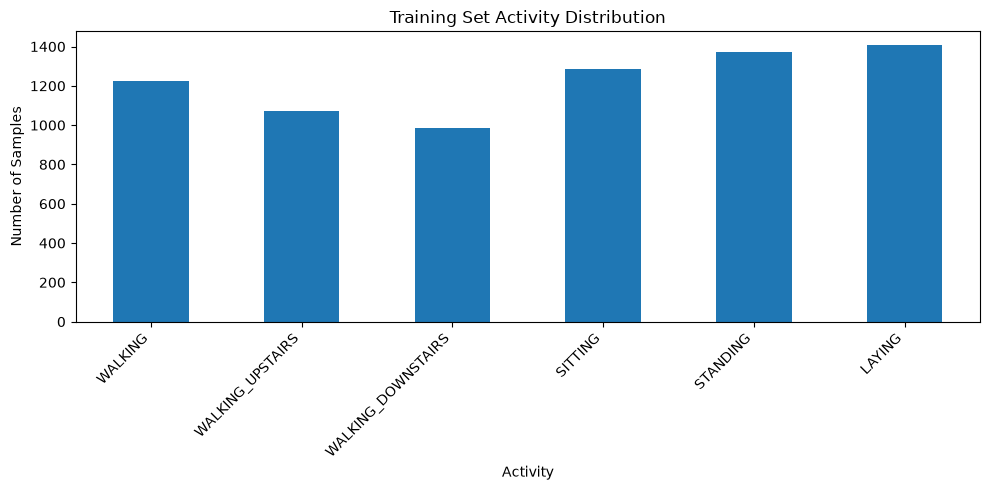

In [13]:
train_class_counts = (
    y_train_names
    .value_counts()
    .reindex(activity_labels_df["activity_name"])
)

train_class_percent = train_class_counts / train_class_counts.sum() * 100

class_distribution = pd.DataFrame({
    "count": train_class_counts,
    "percentage": train_class_percent.round(2)
})

class_distribution
#Plot the training class distribution
plt.figure(figsize=(10, 5))

train_class_counts.plot(kind="bar")

plt.title("Training Set Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

Largest class size: 1407
Smallest class size: 986
Class imbalance ratio: 1.43


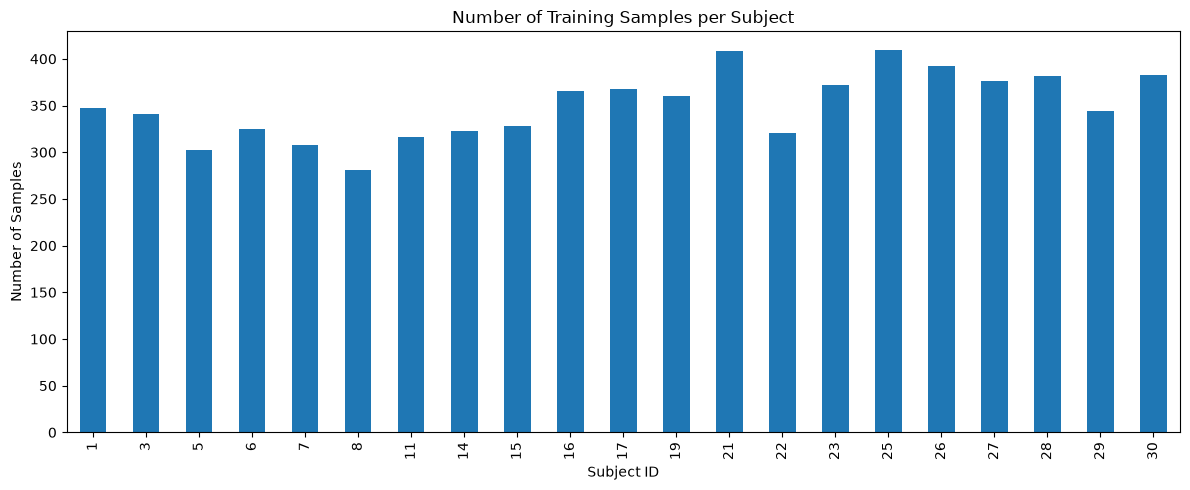

In [14]:
imbalance_ratio = train_class_counts.max() / train_class_counts.min()

print("Largest class size:", train_class_counts.max())
print("Smallest class size:", train_class_counts.min())
print("Class imbalance ratio:", round(imbalance_ratio, 2))

subject_counts = subject_train.value_counts().sort_index()

subject_counts
# To check ifsome participants contribute much more data than others.
plt.figure(figsize=(12, 5))

subject_counts.plot(kind="bar")

plt.title("Number of Training Samples per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Number of Samples")
plt.tight_layout()

plt.show()

In [15]:
feature_summary = X_train.describe().T

feature_summary[["mean", "std", "min", "max"]].head(10)

#To check whether features are already roughly scaled
print("Overall minimum:", X_train.min().min())
print("Overall maximum:", X_train.max().max())

print("\nAverage absolute feature mean:")
print(np.abs(X_train.mean()).mean())

print("\nAverage feature standard deviation:")
print(X_train.std().mean())

Overall minimum: -1.0
Overall maximum: 1.0

Average absolute feature mean:
0.5779252751791852

Average feature standard deviation:
0.2836933644890431


## 6. Participant-Safe Training and Validation Split

A random row-level validation split is avoided because multiple observations from the same participant could otherwise appear in both training and validation sets.

Instead, complete participants are assigned either to the development training set or the validation set.

This provides a stricter evaluation of whether the model generalises to unseen individuals.

In [16]:
unique_train_subjects = np.array(sorted(subject_train.unique()))

print("Official training subjects:")
print(unique_train_subjects)

print("\nNumber of official training subjects:",
      len(unique_train_subjects))

rng = np.random.default_rng(SEED)

shuffled_subjects = unique_train_subjects.copy()
rng.shuffle(shuffled_subjects)

n_val_subjects = 5

val_subjects = set(shuffled_subjects[:n_val_subjects])
dev_train_subjects = set(shuffled_subjects[n_val_subjects:])

print("Development training subjects:")
print(sorted(dev_train_subjects))

print("\nValidation subjects:")
print(sorted(val_subjects))

print("\nNumber of development training subjects:",
      len(dev_train_subjects))

print("Number of validation subjects:",
      len(val_subjects))

Official training subjects:
[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]

Number of official training subjects: 21
Development training subjects:
[np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(19), np.int64(22), np.int64(23), np.int64(27), np.int64(28), np.int64(29)]

Validation subjects:
[np.int64(17), np.int64(21), np.int64(25), np.int64(26), np.int64(30)]

Number of development training subjects: 16
Number of validation subjects: 5


In [17]:
dev_mask = subject_train.isin(dev_train_subjects)  #create masks
val_mask = subject_train.isin(val_subjects)

X_dev = X_train.loc[dev_mask].reset_index(drop=True)
y_dev = y_train.loc[dev_mask].reset_index(drop=True)
subject_dev = subject_train.loc[dev_mask].reset_index(drop=True)

X_val = X_train.loc[val_mask].reset_index(drop=True)
y_val = y_train.loc[val_mask].reset_index(drop=True)
subject_val = subject_train.loc[val_mask].reset_index(drop=True)

print("Development training shape:", X_dev.shape)
print("Validation shape:", X_val.shape)
print("Official test shape:", X_test.shape)

dev_subject_set = set(subject_dev.unique())
val_subject_set = set(subject_val.unique())
test_subject_set = set(subject_test.unique())

print("Dev ∩ Val:",
      dev_subject_set.intersection(val_subject_set))

print("Dev ∩ Test:",
      dev_subject_set.intersection(test_subject_set))

print("Val ∩ Test:",
      val_subject_set.intersection(test_subject_set))

Development training shape: (5392, 561)
Validation shape: (1960, 561)
Official test shape: (2947, 561)
Dev ∩ Val: set()
Dev ∩ Test: set()
Val ∩ Test: set()


In [18]:
assert dev_subject_set.isdisjoint(val_subject_set)
assert dev_subject_set.isdisjoint(test_subject_set)
assert val_subject_set.isdisjoint(test_subject_set)

assert len(X_dev) == len(y_dev) == len(subject_dev)
assert len(X_val) == len(y_val) == len(subject_val)

print("Participant-safe split verified successfully.")

y_dev_model = y_dev - 1
y_val_model = y_val - 1
y_test_model = y_test - 1

print("Development labels:",
      sorted(y_dev_model.unique()))

print("Validation labels:",
      sorted(y_val_model.unique()))

print("Test labels:",
      sorted(y_test_model.unique()))

print("Development class counts:")
print(
    y_dev.map(activity_map)
    .value_counts()
    .reindex(activity_labels_df["activity_name"])
)

print("\nValidation class counts:")
print(
    y_val.map(activity_map)
    .value_counts()
    .reindex(activity_labels_df["activity_name"])
)

assert y_dev.nunique() == 6
assert y_val.nunique() == 6
assert y_test.nunique() == 6

print("All six activities are represented in every split.")

Participant-safe split verified successfully.
Development labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Development class counts:
activity_name
WALKING                915
WALKING_UPSTAIRS       793
WALKING_DOWNSTAIRS     725
SITTING                932
STANDING              1000
LAYING                1027
Name: count, dtype: int64

Validation class counts:
activity_name
WALKING               311
WALKING_UPSTAIRS      280
WALKING_DOWNSTAIRS    261
SITTING               354
STANDING              374
LAYING                380
Name: count, dtype: int64
All six activities are represented in every split.


## 7. Preprocessing

The 561 input features are numerical sensor-derived features. To ensure that the classical baseline and neural network models are trained on a consistent scale, standardisation is applied.

The scaler is fitted only on the development training set. The same fitted transformation is then applied to the validation and test sets.

This avoids data leakage from the validation or test partitions into the model-training process.

In [19]:
scaler = StandardScaler()

X_dev_scaled = scaler.fit_transform(X_dev)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled development shape:", X_dev_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("Mean of scaled development data:",
      round(float(X_dev_scaled.mean()), 6))

print("Std of scaled development data:",
      round(float(X_dev_scaled.std()), 6))

Scaled development shape: (5392, 561)
Scaled validation shape: (1960, 561)
Scaled test shape: (2947, 561)
Mean of scaled development data: 0.0
Std of scaled development data: 1.0


## 8. Naive Baseline: Majority-Class Classifier

A majority-class classifier is used as the simplest baseline.

This model ignores all sensor features and always predicts the activity that occurs most frequently in the development training data.

The purpose of this baseline is to establish the minimum performance that a useful model should exceed.

In [20]:
dummy_clf = DummyClassifier(
    strategy="most_frequent"
)

dummy_clf.fit(X_dev_scaled, y_dev_model)

dummy_val_pred = dummy_clf.predict(X_val_scaled)

dummy_val_accuracy = accuracy_score(
    y_val_model,
    dummy_val_pred
)

print("Majority-class validation accuracy:",
      round(dummy_val_accuracy, 4))

dummy_class = int(dummy_clf.predict(X_val_scaled[:1])[0])

dummy_activity_name = activity_map[dummy_class + 1]

print("Majority class predicted by baseline:",
      dummy_activity_name)

Majority-class validation accuracy: 0.1939
Majority class predicted by baseline: LAYING


                    precision    recall  f1-score   support

           WALKING       0.00      0.00      0.00       311
  WALKING_UPSTAIRS       0.00      0.00      0.00       280
WALKING_DOWNSTAIRS       0.00      0.00      0.00       261
           SITTING       0.00      0.00      0.00       354
          STANDING       0.00      0.00      0.00       374
            LAYING       0.19      1.00      0.32       380

          accuracy                           0.19      1960
         macro avg       0.03      0.17      0.05      1960
      weighted avg       0.04      0.19      0.06      1960



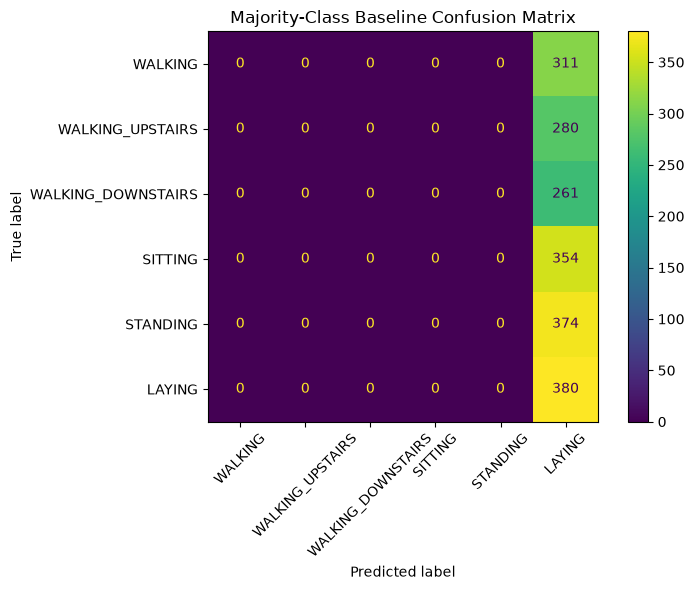

In [21]:
target_names = [
    activity_map[i]
    for i in sorted(activity_map.keys())
]

print(
    classification_report(
        y_val_model,
        dummy_val_pred,
        target_names=target_names,
        zero_division=0
    )
)
# create confusion matrix
cm_dummy = confusion_matrix(
    y_val_model,
    dummy_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dummy,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Majority-Class Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
results_table = pd.DataFrame([
    {
        "Model": "Majority Class Baseline",
        "Validation Accuracy": dummy_val_accuracy
    }
])

results_table

,Model,Validation Accuracy
0,Majority Class Baseline,0.193878


## 9. Strong Classical Baseline: Multinomial Logistic Regression

A multinomial logistic regression model is used as a stronger classical baseline.

Unlike the majority-class classifier, logistic regression uses all 561 sensor-derived features. This tests whether the activity classes can already be separated effectively using a linear decision boundary.

The model is trained on the development training partition and evaluated on the participant-safe validation set. The official test set is not used in this section.

In [23]:
# Create and train the Logistic Regression baseline

log_reg = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

log_reg.fit(
    X_dev_scaled,
    y_dev_model
)

print("Logistic Regression training completed.")

# Predict on the participant-safe validation set

logreg_val_pred = log_reg.predict(
    X_val_scaled
)

logreg_val_accuracy = accuracy_score(
    y_val_model,
    logreg_val_pred
)

print(
    "Logistic Regression validation accuracy:",
    round(logreg_val_accuracy, 4)
)
# Validation classification report

print(
    classification_report(
        y_val_model,
        logreg_val_pred,
        target_names=target_names,
        zero_division=0
    )
)

Logistic Regression training completed.
Logistic Regression validation accuracy: 0.9561
                    precision    recall  f1-score   support

           WALKING       0.94      1.00      0.97       311
  WALKING_UPSTAIRS       0.93      1.00      0.96       280
WALKING_DOWNSTAIRS       1.00      0.84      0.91       261
           SITTING       0.96      0.91      0.93       354
          STANDING       0.92      0.97      0.94       374
            LAYING       1.00      1.00      1.00       380

          accuracy                           0.96      1960
         macro avg       0.96      0.95      0.95      1960
      weighted avg       0.96      0.96      0.96      1960



In [24]:
# Store class-level validation metrics for later analysis

logreg_report = classification_report(
    y_val_model,
    logreg_val_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

logreg_report_df = pd.DataFrame(
    logreg_report
).T

logreg_report_df

,precision,recall,f1-score,support
WALKING,0.942424,1.000000,0.970359,311.000000
WALKING_UPSTAIRS,0.926910,0.996429,0.960413,280.000000
WALKING_DOWNSTAIRS,1.000000,0.842912,0.914761,261.000000
SITTING,0.963964,0.906780,0.934498,354.000000
STANDING,0.916667,0.970588,0.942857,374.000000
LAYING,1.000000,1.000000,1.000000,380.000000
accuracy,0.956122,0.956122,0.956122,0.956122
macro avg,0.958328,0.952785,0.953815,1960.000000
weighted avg,0.958013,0.956122,0.955556,1960.000000


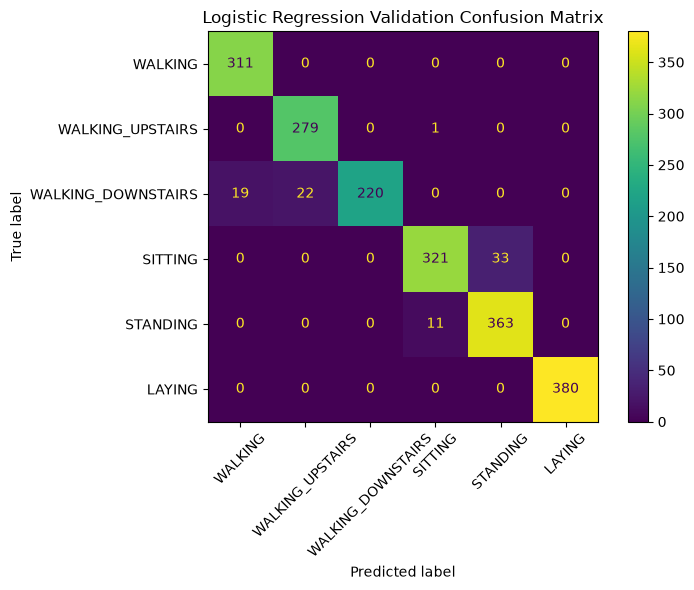

In [25]:
# Validation confusion matrix

cm_logreg = confusion_matrix(
    y_val_model,
    logreg_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=target_names
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Logistic Regression Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [26]:
# Add Logistic Regression validation performance
# to the model comparison table

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([
            {
                "Model": "Logistic Regression",
                "Validation Accuracy": logreg_val_accuracy
            }
        ])
    ],
    ignore_index=True
)

results_table

,Model,Validation Accuracy
0,Majority Class Baseline,0.193878
1,Logistic Regression,0.956122


In [27]:
# Compare Logistic Regression against
# the naive majority-class baseline

absolute_improvement = (
    logreg_val_accuracy
    - dummy_val_accuracy
)

relative_improvement = (
    absolute_improvement
    / dummy_val_accuracy
)

print(
    "Absolute accuracy improvement:",
    round(absolute_improvement, 4)
)

print(
    "Relative improvement over majority baseline:",
    round(relative_improvement * 100, 2),
    "%"
)

Absolute accuracy improvement: 0.7622
Relative improvement over majority baseline: 393.16 %


### Logistic Regression Validation Result

Logistic Regression achieved strong validation performance and substantially outperformed the majority-class baseline.

This indicates that the engineered UCI HAR features already contain highly discriminative information that can be separated effectively using a linear model.

The class-level results also show that some activities are easier to distinguish than others. In particular, LAYING is highly separable, while some confusion remains among walking-related activities and between SITTING and STANDING.

This model is retained as the strongest classical baseline for comparison with the TensorFlow/Keras neural networks.

## 10. Keras Linear Baseline

A single-layer neural network with a six-class Softmax output is used as the first TensorFlow/Keras baseline.

This model has no hidden layers, so it acts as a linear classifier. Its purpose is to establish whether the TensorFlow implementation can reproduce performance comparable to a traditional linear model before introducing nonlinear hidden layers.

The model is trained only on the development training partition and monitored using the participant-safe validation set.

In [28]:
keras.utils.set_random_seed(SEED)

linear_keras_model = keras.Sequential([
    layers.Input(shape=(X_dev_scaled.shape[1],)),
    layers.Dense(6, activation="softmax")
])

linear_keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

linear_keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │         3,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,372 (13.17 KB)

 Trainable params: 3,372 (13.17 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
linear_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

linear_history = linear_keras_model.fit(
    X_dev_scaled,
    y_dev_model,
    validation_data=(X_val_scaled, y_val_model),
    epochs=100,
    batch_size=32,
    callbacks=linear_callbacks,
    verbose=1
)
linear_val_loss, linear_val_accuracy = linear_keras_model.evaluate(
    X_val_scaled,
    y_val_model,
    verbose=0
)

print("Keras linear validation loss:",
      round(linear_val_loss, 4))

print("Keras linear validation accuracy:",
      round(linear_val_accuracy, 4))

Epoch 1/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8071 - loss: 0.5379 - val_accuracy: 0.8781 - val_loss: 0.3166
Epoch 2/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.9379 - loss: 0.1979 - val_accuracy: 0.9071 - val_loss: 0.2391
Epoch 3/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9588 - loss: 0.1407 - val_accuracy: 0.9214 - val_loss: 0.2058
Epoch 4/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.9674 - loss: 0.1127 - val_accuracy: 0.9265 - val_loss: 0.1872
Epoch 5/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.9737 - loss: 0.0957 - val_accuracy: 0.9327 - val_loss: 0.1753
Epoch 6/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9781 - loss: 0.0843 - val_accuracy: 0.9342 - val_loss: 0.1672
Epoch 7/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.9807 - loss: 0.0761 - val_accuracy: 0.9342 - val_loss: 0.1613
Epoch 8/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.9818 - loss: 0.0

                    precision    recall  f1-score   support

           WALKING       0.94      1.00      0.97       311
  WALKING_UPSTAIRS       0.93      1.00      0.96       280
WALKING_DOWNSTAIRS       1.00      0.84      0.91       261
           SITTING       0.96      0.87      0.91       354
          STANDING       0.89      0.97      0.93       374
            LAYING       1.00      1.00      1.00       380

          accuracy                           0.95      1960
         macro avg       0.95      0.95      0.95      1960
      weighted avg       0.95      0.95      0.95      1960



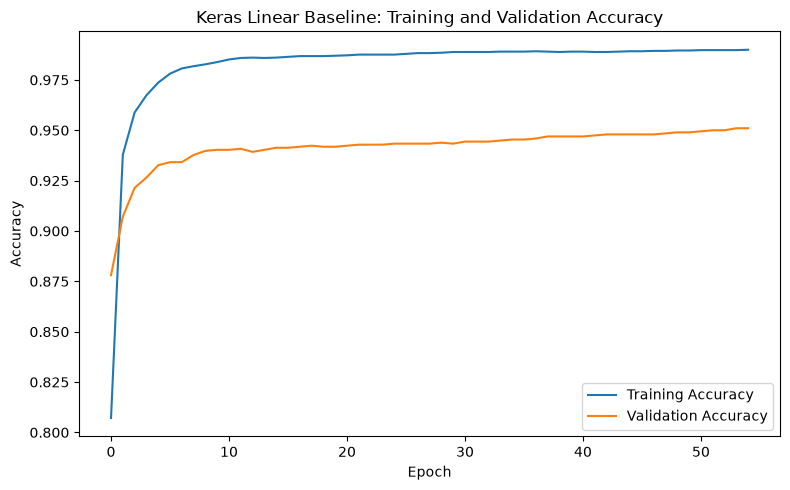

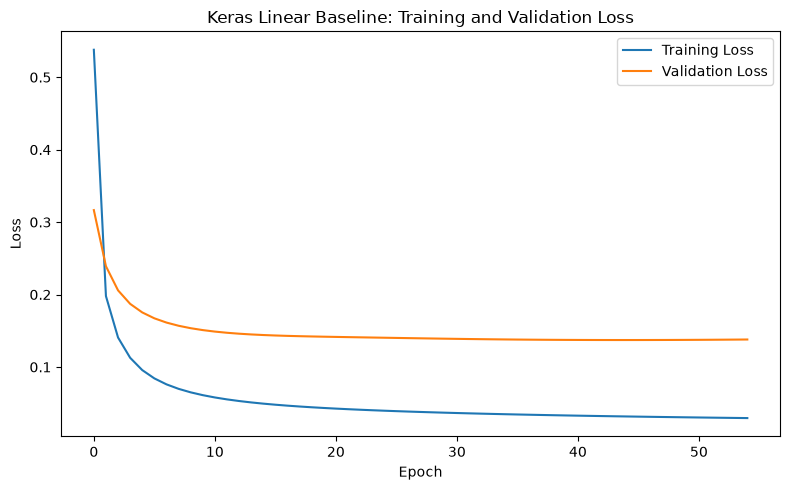

In [30]:
# Plot training and validation loss and accuracy
linear_val_prob = linear_keras_model.predict(
    X_val_scaled,
    verbose=0
)

linear_val_pred = np.argmax(
    linear_val_prob,
    axis=1
)

print(
    classification_report(
        y_val_model,
        linear_val_pred,
        target_names=target_names,
        zero_division=0
    )
)
plt.figure(figsize=(8, 5))

plt.plot(
    linear_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    linear_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras Linear Baseline: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# loss plot
plt.figure(figsize=(8, 5))

plt.plot(
    linear_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    linear_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras Linear Baseline: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([
            {
                "Model": "Keras Linear Softmax",
                "Validation Accuracy": linear_val_accuracy
            }
        ])
    ],
    ignore_index=True
)

results_table

,Model,Validation Accuracy
0,Majority Class Baseline,0.193878
1,Logistic Regression,0.956122
2,Keras Linear Softmax,0.947959


In [32]:
results_table.sort_values(
    "Validation Accuracy",
    ascending=False
)

,Model,Validation Accuracy
1,Logistic Regression,0.956122
2,Keras Linear Softmax,0.947959
0,Majority Class Baseline,0.193878


## 11. Small Multilayer Perceptron

A small multilayer perceptron (MLP) is introduced to test whether nonlinear hidden representations improve activity classification over the linear baselines.

The network uses one hidden Dense layer with ReLU activation followed by a six-class Softmax output layer.

This model is intentionally kept small so that its performance can be compared fairly with the later deeper and regularised neural network.

In [33]:
keras.utils.set_random_seed(SEED)

small_mlp = keras.Sequential([
    layers.Input(shape=(X_dev_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(6, activation="softmax")
])

small_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

small_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        35,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
small_mlp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]
small_mlp_history = small_mlp.fit(
    X_dev_scaled,
    y_dev_model,
    validation_data=(X_val_scaled, y_val_model),
    epochs=100,
    batch_size=32,
    callbacks=small_mlp_callbacks,
    verbose=1
)
small_mlp_val_loss, small_mlp_val_accuracy = small_mlp.evaluate(
    X_val_scaled,
    y_val_model,
    verbose=0
)

print("Small MLP validation loss:",
      round(small_mlp_val_loss, 4))

print("Small MLP validation accuracy:",
      round(small_mlp_val_accuracy, 4))

Epoch 1/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8765 - loss: 0.3235 - val_accuracy: 0.9061 - val_loss: 0.2537
Epoch 2/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.9644 - loss: 0.0990 - val_accuracy: 0.9117 - val_loss: 0.2306
Epoch 3/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9727 - loss: 0.0719 - val_accuracy: 0.9153 - val_loss: 0.2340
Epoch 4/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.9785 - loss: 0.0587 - val_accuracy: 0.9168 - val_loss: 0.2383
Epoch 5/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.9805 - loss: 0.0512 - val_accuracy: 0.9184 - val_loss: 0.2271
Epoch 6/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9833 - loss: 0.0446 - val_accuracy: 0.9316 - val_loss: 0.1829
Epoch 7/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9850 - loss: 0.0404 - val_accuracy: 0.9311 - val_loss: 0.1894
Epoch 8/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9870 - loss: 0.0

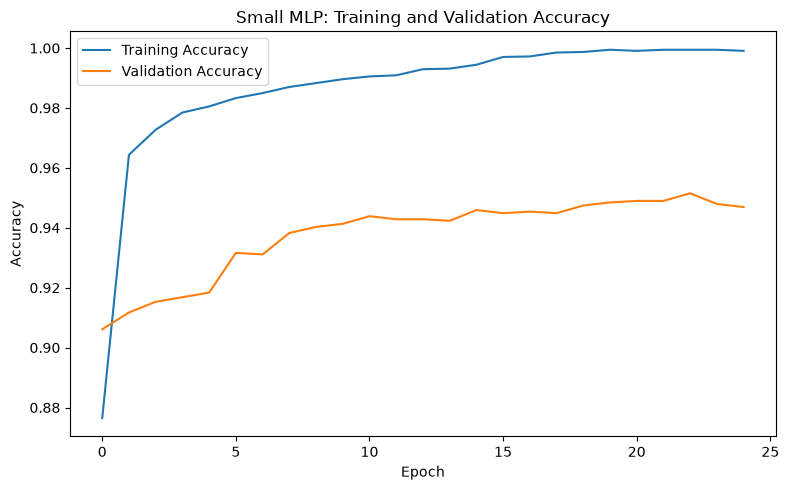

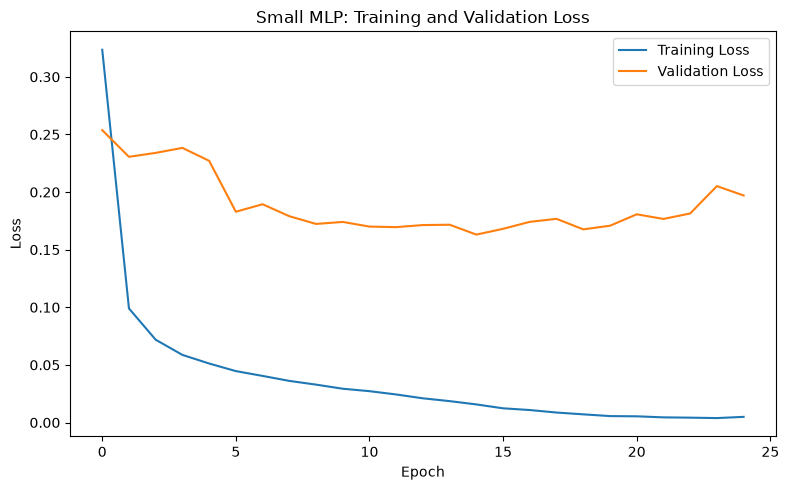

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    small_mlp_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    small_mlp_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Small MLP: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    small_mlp_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    small_mlp_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Small MLP: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([
            {
                "Model": "Small MLP (64 ReLU)",
                "Validation Accuracy": small_mlp_val_accuracy
            }
        ])
    ],
    ignore_index=True
)

results_table.sort_values(
    "Validation Accuracy",
    ascending=False
)

,Model,Validation Accuracy
1,Logistic Regression,0.956122
2,Keras Linear Softmax,0.947959
3,Small MLP (64 ReLU),0.945918
0,Majority Class Baseline,0.193878


## 12. Deep MLP Without Regularisation

A deeper multilayer perceptron is trained to test whether additional nonlinear capacity improves activity classification.

The network contains three hidden Dense layers with ReLU activation. No dropout or other explicit regularisation is used in this experiment.

This model provides a comparison point for the following regularised network, allowing the effect of regularisation to be evaluated while keeping the overall architecture similar.

In [37]:
keras.utils.set_random_seed(SEED)

deep_mlp = keras.Sequential([
    layers.Input(shape=(X_dev_scaled.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(6, activation="softmax")
])

deep_mlp.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

deep_mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,414 (724.27 KB)

 Trainable params: 185,414 (724.27 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
deep_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]
deep_history = deep_mlp.fit(
    X_dev_scaled,
    y_dev_model,
    validation_data=(
        X_val_scaled,
        y_val_model
    ),
    epochs=150,
    batch_size=32,
    callbacks=deep_callbacks,
    verbose=1
)

Epoch 1/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9067 - loss: 0.2409 - val_accuracy: 0.9204 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 2/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9614 - loss: 0.0973 - val_accuracy: 0.9352 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 3/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9720 - loss: 0.0704 - val_accuracy: 0.9184 - val_loss: 0.2473 - learning_rate: 0.0010
Epoch 4/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9798 - loss: 0.0578 - val_accuracy: 0.9189 - val_loss: 0.2667 - learning_rate: 0.0010
Epoch 5/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9829 - loss: 0.0445 - val_accuracy: 0.9168 - val_loss: 0.2776 - learning_rate: 0.0010
Epoch 6/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9853 - loss: 0.0398 - val_accuracy: 0.9372 - val_loss: 0.1924 - learning_rate: 0.0010
Epoch 7/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9892 - loss: 0.

In [39]:
deep_val_loss, deep_val_accuracy = deep_mlp.evaluate(
    X_val_scaled,
    y_val_model,
    verbose=0
)

print(
    "Deep MLP validation loss:",
    round(deep_val_loss, 4)
)

print(
    "Deep MLP validation accuracy:",
    round(deep_val_accuracy, 4)
)
deep_val_prob = deep_mlp.predict(
    X_val_scaled,
    verbose=0
)

deep_val_pred = np.argmax(
    deep_val_prob,
    axis=1
)

print(
    classification_report(
        y_val_model,
        deep_val_pred,
        target_names=target_names,
        zero_division=0
    )
)

Deep MLP validation loss: 0.1924
Deep MLP validation accuracy: 0.9372
                    precision    recall  f1-score   support

           WALKING       0.96      1.00      0.98       311
  WALKING_UPSTAIRS       0.94      0.98      0.96       280
WALKING_DOWNSTAIRS       0.99      0.89      0.94       261
           SITTING       0.97      0.78      0.86       354
          STANDING       0.82      0.97      0.89       374
            LAYING       1.00      1.00      1.00       380

          accuracy                           0.94      1960
         macro avg       0.95      0.94      0.94      1960
      weighted avg       0.94      0.94      0.94      1960



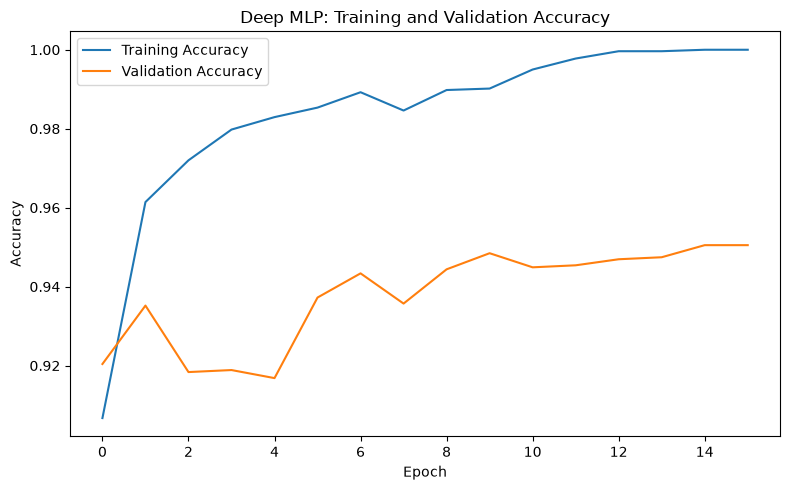

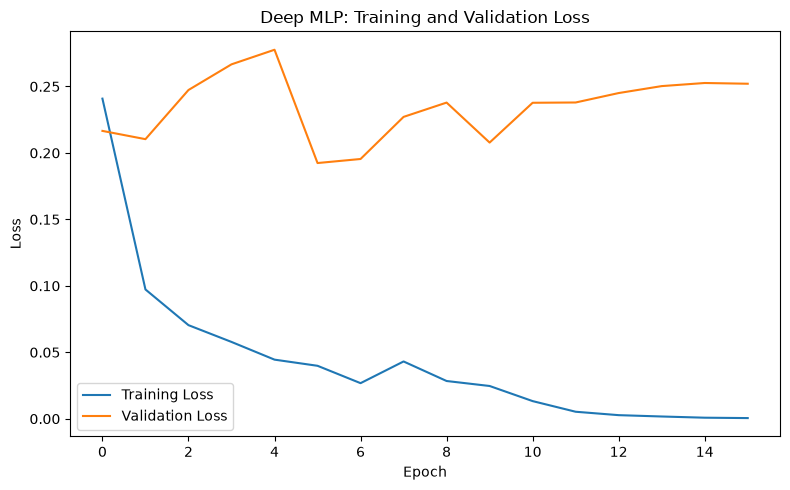

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    deep_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    deep_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Deep MLP: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    deep_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    deep_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep MLP: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([
            {
                "Model": "Deep MLP (256-128-64)",
                "Validation Accuracy": deep_val_accuracy
            }
        ])
    ],
    ignore_index=True
)

results_table.sort_values(
    "Validation Accuracy",
    ascending=False
)

,Model,Validation Accuracy
1,Logistic Regression,0.956122
2,Keras Linear Softmax,0.947959
3,Small MLP (64 ReLU),0.945918
4,Deep MLP (256-128-64),0.937245
0,Majority Class Baseline,0.193878


In [42]:
deep_epochs_run = len(
    deep_history.history["loss"]
)

best_deep_epoch = (
    np.argmin(
        deep_history.history["val_loss"]
    ) + 1
)

print(
    "Epochs actually run:",
    deep_epochs_run
)

print(
    "Best validation-loss epoch:",
    best_deep_epoch
)

print(
    "Best validation loss:",
    round(
        min(
            deep_history.history["val_loss"]
        ),
        4
    )
)

Epochs actually run: 16
Best validation-loss epoch: 6
Best validation loss: 0.1924


## 13. Regularised Deep MLP

The unregularised deep MLP showed lower validation accuracy than the simpler baselines and reached its best validation loss early in training.

To test whether overfitting is limiting generalisation, a regularised version of the deep network is trained using dropout and L2 weight regularisation.

The architecture remains broadly similar so that the effect of regularisation can be evaluated more directly.

In [43]:
keras.utils.set_random_seed(SEED)

regularized_mlp = keras.Sequential([
    layers.Input(shape=(X_dev_scaled.shape[1],)),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.30),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.30),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),

    layers.Dense(6, activation="softmax")
])

regularized_mlp.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_mlp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,414 (724.27 KB)

 Trainable params: 185,414 (724.27 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
regularized_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]
regularized_history = regularized_mlp.fit(
    X_dev_scaled,
    y_dev_model,
    validation_data=(
        X_val_scaled,
        y_val_model
    ),
    epochs=150,
    batch_size=32,
    callbacks=regularized_callbacks,
    verbose=1
)
regularized_val_loss, regularized_val_accuracy = (
    regularized_mlp.evaluate(
        X_val_scaled,
        y_val_model,
        verbose=0
    )
)

print(
    "Regularized MLP validation loss:",
    round(regularized_val_loss, 4)
)

print(
    "Regularized MLP validation accuracy:",
    round(regularized_val_accuracy, 4)
)

Epoch 1/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 0.5007 - val_accuracy: 0.9026 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 2/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9266 - loss: 0.2502 - val_accuracy: 0.8786 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 3/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9529 - loss: 0.1809 - val_accuracy: 0.8964 - val_loss: 0.3038 - learning_rate: 0.0010
Epoch 4/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9579 - loss: 0.1717 - val_accuracy: 0.9128 - val_loss: 0.3742 - learning_rate: 0.0010
Epoch 5/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9662 - loss: 0.1530 - val_accuracy: 0.9260 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 6/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9683 - loss: 0.1488 - val_accuracy: 0.9276 - val_loss: 0.2689 - learning_rate: 0.0010
Epoch 7/150
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9718 - loss: 0.

In [45]:
regularized_val_prob = regularized_mlp.predict(
    X_val_scaled,
    verbose=0
)

regularized_val_pred = np.argmax(
    regularized_val_prob,
    axis=1
)

print(
    classification_report(
        y_val_model,
        regularized_val_pred,
        target_names=target_names,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

           WALKING       0.99      0.98      0.99       311
  WALKING_UPSTAIRS       0.93      0.95      0.94       280
WALKING_DOWNSTAIRS       0.92      0.92      0.92       261
           SITTING       0.96      0.83      0.89       354
          STANDING       0.86      0.97      0.91       374
            LAYING       1.00      1.00      1.00       380

          accuracy                           0.94      1960
         macro avg       0.94      0.94      0.94      1960
      weighted avg       0.95      0.94      0.94      1960



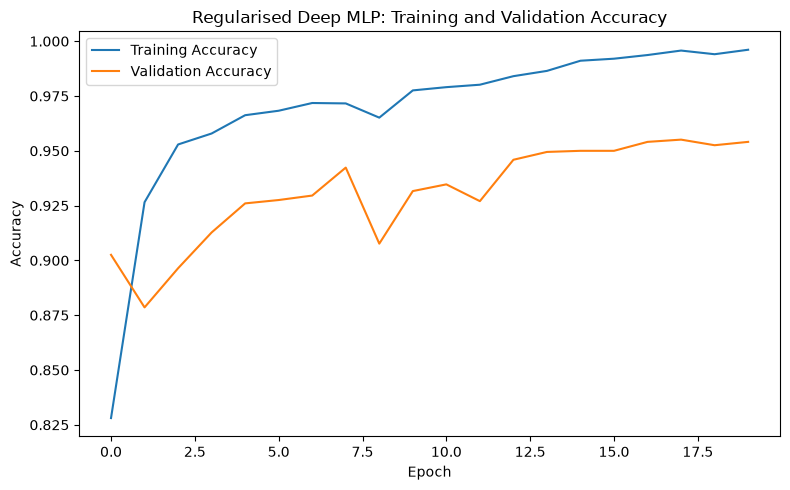

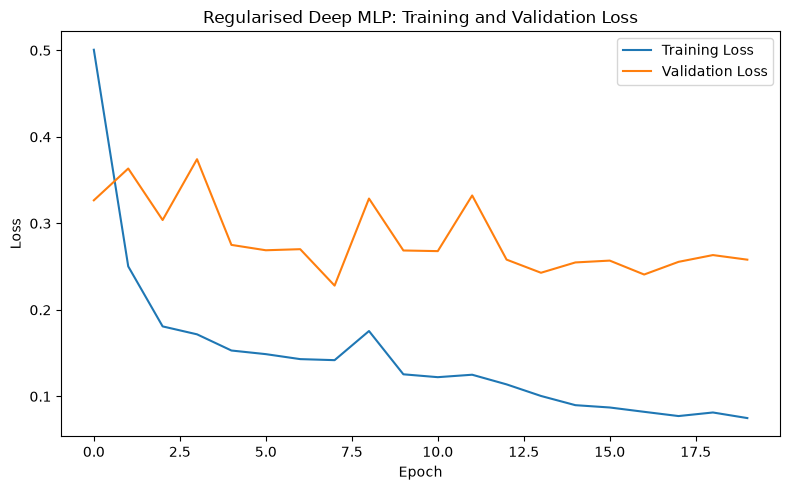

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(
    regularized_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    regularized_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularised Deep MLP: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    regularized_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    regularized_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularised Deep MLP: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
regularized_epochs_run = len(
    regularized_history.history["loss"]
)

best_regularized_epoch = (
    np.argmin(
        regularized_history.history["val_loss"]
    ) + 1
)

print(
    "Epochs actually run:",
    regularized_epochs_run
)

print(
    "Best validation-loss epoch:",
    best_regularized_epoch
)

print(
    "Best validation loss:",
    round(
        min(
            regularized_history.history["val_loss"]
        ),
        4
    )
)

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([
            {
                "Model":
                "Regularised Deep MLP",
                "Validation Accuracy":
                regularized_val_accuracy
            }
        ])
    ],
    ignore_index=True
)

results_table.sort_values(
    "Validation Accuracy",
    ascending=False
)

Epochs actually run: 20
Best validation-loss epoch: 8
Best validation loss: 0.228


,Model,Validation Accuracy
1,Logistic Regression,0.956122
2,Keras Linear Softmax,0.947959
3,Small MLP (64 ReLU),0.945918
5,Regularised Deep MLP,0.942347
4,Deep MLP (256-128-64),0.937245
0,Majority Class Baseline,0.193878


## 14. Model Selection

Model selection is based only on performance on the participant-safe validation set.

Logistic regression achieved the highest validation accuracy overall. Among the TensorFlow/Keras models, the regularised deep MLP achieved the highest validation accuracy.

Because the objective of this project is to design and evaluate a deep learning solution, the regularised deep MLP is selected as the final deep learning model. Logistic regression is retained as a strong classical baseline for comparison.
The held-out official test set has not been used for model selection.

In [49]:
best_reg_acc_epoch = (
    np.argmax(
        regularized_history.history["val_accuracy"]
    ) + 1
)

best_reg_val_accuracy = max(
    regularized_history.history["val_accuracy"]
)

print(
    "Best validation-accuracy epoch:",
    best_reg_acc_epoch
)

print(
    "Best validation accuracy observed:",
    round(best_reg_val_accuracy, 4)
)

print(
    "Best validation-loss epoch:",
    best_regularized_epoch
)

reg_gain = (
    regularized_val_accuracy
    - deep_val_accuracy
)

print(
    "Validation accuracy gain from regularisation:",
    round(reg_gain, 4)
)

print(
    "Gain in percentage points:",
    round(reg_gain * 100, 2)
)

Best validation-accuracy epoch: 18
Best validation accuracy observed: 0.9551
Best validation-loss epoch: 8
Validation accuracy gain from regularisation: 0.0051
Gain in percentage points: 0.51


In [50]:
gap_to_logreg = (
    logreg_val_accuracy
    - regularized_val_accuracy
)

print(
    "Gap between Logistic Regression and Regularised MLP:",
    round(gap_to_logreg * 100, 2),
    "percentage points"
)

Gap between Logistic Regression and Regularised MLP: 1.38 percentage points


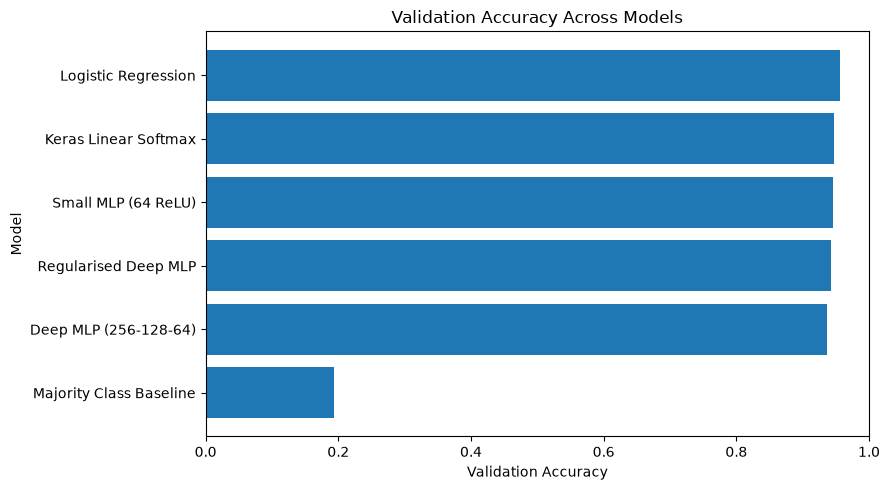

In [51]:
comparison_plot = (
    results_table
    .sort_values(
        "Validation Accuracy",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    comparison_plot["Model"],
    comparison_plot["Validation Accuracy"]
)

plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.title("Validation Accuracy Across Models")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

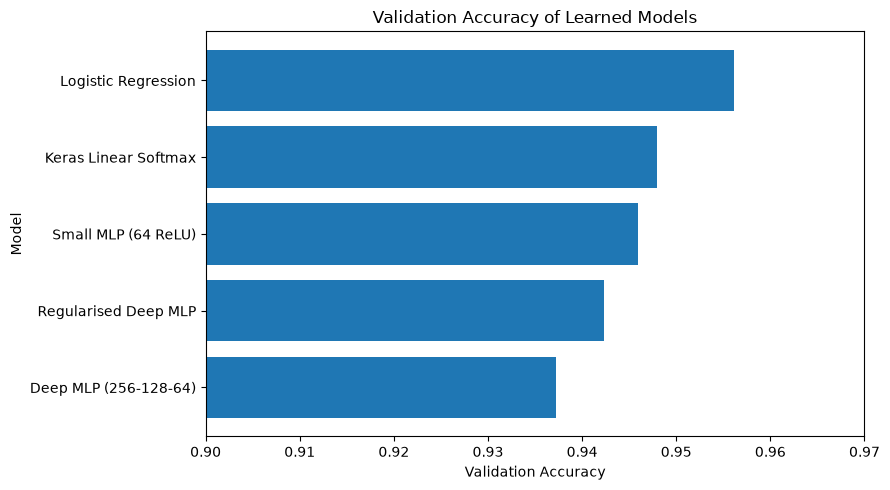

In [52]:
competitive_models = results_table[
    results_table["Model"]
    != "Majority Class Baseline"
].sort_values(
    "Validation Accuracy",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    competitive_models["Model"],
    competitive_models["Validation Accuracy"]
)

plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.title("Validation Accuracy of Learned Models")

plt.xlim(0.90, 0.97)

plt.tight_layout()
plt.show()

In [53]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results_table.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR / "validation_model_comparison.csv"
)
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

regularized_mlp.save(
    MODELS_DIR / "regularized_har_model.keras"
)

print(
    "Final Keras model saved."
)

Saved: /Users/nehasingh/DATAX504-nsingh1811/final-project/results/validation_model_comparison.csv
Final Keras model saved.


## 15. Final Evaluation on the Held-Out Test Set

After model selection was completed using the participant-safe validation set, the two selected models were evaluated on the official UCI test set:

1. Logistic Regression — the strongest classical baseline.
2. Regularised Deep MLP — the strongest TensorFlow/Keras model.

The official test set was not used for model selection or hyperparameter tuning. No model changes were made after viewing the test results.

In [ ]:
# Logistic Regression: final test evaluation

logreg_test_pred = log_reg.predict(
    X_test_scaled
)
logreg_test_accuracy = accuracy_score(
    y_test_model,
    logreg_test_pred
)
print(
    "Logistic Regression test accuracy:",
    round(logreg_test_accuracy, 4)
)
# Logistic Regression: test classification report

print(
    classification_report(
        y_test_model,
        logreg_test_pred,
        target_names=target_names,
        zero_division=0
    )
)
# Regularised Deep MLP: final test evaluation

regularized_test_loss, regularized_test_accuracy = (
    regularized_mlp.evaluate(
        X_test_scaled,
        y_test_model,
        verbose=0
    )
)
print(
    "Regularised Deep MLP test loss:",
    round(regularized_test_loss, 4)
)
print(
    "Regularised Deep MLP test accuracy:",
    round(regularized_test_accuracy, 4)
)

Logistic Regression test accuracy: 0.9484
                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
  WALKING_UPSTAIRS       0.94      0.96      0.95       471
WALKING_DOWNSTAIRS       0.98      0.90      0.93       420
           SITTING       0.97      0.87      0.92       491
          STANDING       0.88      0.97      0.93       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947

Regularised Deep MLP test loss: 0.2441
Regularised Deep MLP test accuracy: 0.9508


In [ ]:
# Regularised Deep MLP: test predictions

regularized_test_prob = regularized_mlp.predict(
    X_test_scaled,
    verbose=0
)

regularized_test_pred = np.argmax(
    regularized_test_prob,
    axis=1
)
# Regularised Deep MLP: test classification report

print(
    classification_report(
        y_test_model,
        regularized_test_pred,
        target_names=target_names,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

           WALKING       0.95      0.98      0.96       496
  WALKING_UPSTAIRS       0.93      0.97      0.95       471
WALKING_DOWNSTAIRS       0.98      0.89      0.93       420
           SITTING       0.95      0.89      0.92       491
          STANDING       0.91      0.96      0.93       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [ ]:
regularized_test_report = classification_report(
    y_test_model,
    regularized_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

regularized_test_report_df = pd.DataFrame(
    regularized_test_report
).T

regularized_test_report_df

,precision,recall,f1-score,support
WALKING,0.945419,0.977823,0.961348,496.000000
WALKING_UPSTAIRS,0.929150,0.974522,0.951295,471.000000
WALKING_DOWNSTAIRS,0.981627,0.890476,0.933833,420.000000
SITTING,0.952070,0.890020,0.920000,491.000000
STANDING,0.905861,0.958647,0.931507,532.000000
LAYING,1.000000,1.000000,1.000000,537.000000
accuracy,0.950797,0.950797,0.950797,0.950797
macro avg,0.952355,0.948581,0.949664,2947.000000
weighted avg,0.951892,0.950797,0.950587,2947.000000


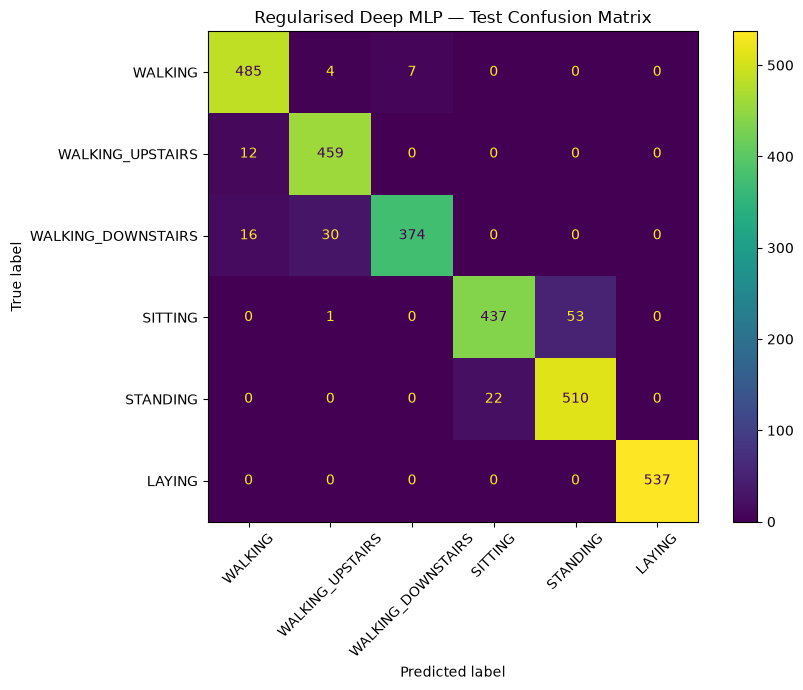

In [ ]:
# Regularised Deep MLP: final test confusion matrix

cm_regularized_test = confusion_matrix(
    y_test_model,
    regularized_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_regularized_test,
    display_labels=target_names
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Regularised Deep MLP — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

fig.savefig(
    RESULTS_DIR / "regularized_mlp_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
# Final validation vs test comparison

final_test_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Validation Accuracy": logreg_val_accuracy,
        "Test Accuracy": logreg_test_accuracy
    },
    {
        "Model": "Regularised Deep MLP",
        "Validation Accuracy": regularized_val_accuracy,
        "Test Accuracy": regularized_test_accuracy
    }
])

final_test_results["Validation-Test Gap"] = (
    final_test_results["Validation Accuracy"]
    - final_test_results["Test Accuracy"]
)

final_test_results

,Model,Validation Accuracy,Test Accuracy,Validation-Test Gap
0,Logistic Regression,0.956122,0.948422,0.007700
1,Regularised Deep MLP,0.952041,0.950797,0.001243


In [ ]:
final_test_results.to_csv(
    RESULTS_DIR / "final_test_results.csv",
    index=False
)

print("Final test results saved.")

Final test results saved.


## 16. Error Analysis
Overall test accuracy provides a useful summary, but it does not show which activities are difficult for the model.

This section analyses the final Regularised Deep MLP in more detail using:
- the test confusion matrix,
- the largest confusion pairs,
- per-class precision, recall, and F1-score,
- and prediction-confidence behaviour.
The aim is to identify where the model fails and whether incorrect predictions are associated with lower confidence.

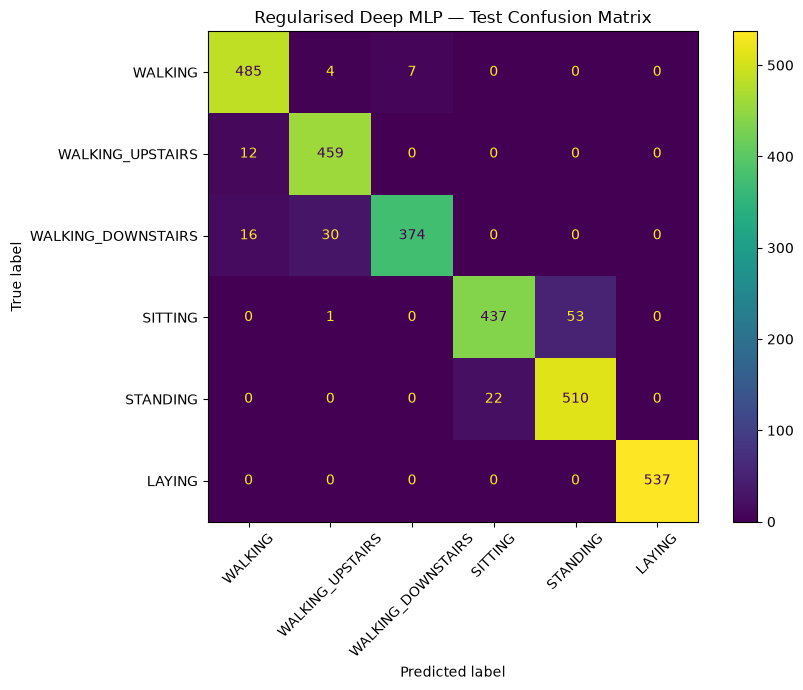

In [ ]:
# Reuse the final test confusion matrix

cm_regularized_test = confusion_matrix(
    y_test_model,
    regularized_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_regularized_test,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Regularised Deep MLP — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 16.1 Largest Confusion Pairs

The off-diagonal entries of the confusion matrix show which activity pairs are most often confused.
Correct predictions are removed from consideration so that the largest remaining error counts can be ranked directly.

In [ ]:
# Extract largest confusion pairs

cm_errors = cm_regularized_test.copy()

# Remove correct predictions
np.fill_diagonal(cm_errors, 0)

error_pairs = []

for true_idx in range(len(target_names)):
    for pred_idx in range(len(target_names)):
        count = cm_errors[true_idx, pred_idx]

        if count > 0:
            error_pairs.append({
                "True Activity": target_names[true_idx],
                "Predicted Activity": target_names[pred_idx],
                "Count": int(count)
            })

error_pairs_df = (
    pd.DataFrame(error_pairs)
    .sort_values(
        "Count",
        ascending=False
    )
    .reset_index(drop=True)
)

error_pairs_df.head(10)

,True Activity,Predicted Activity,Count
0,SITTING,STANDING,53
1,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,30
2,STANDING,SITTING,22
3,WALKING_DOWNSTAIRS,WALKING,16
4,WALKING_UPSTAIRS,WALKING,12
5,WALKING,WALKING_DOWNSTAIRS,7
6,WALKING,WALKING_UPSTAIRS,4
7,SITTING,WALKING_UPSTAIRS,1


The largest errors are concentrated among similar activity types.
In particular, SITTING and STANDING are frequently confused, which is reasonable because both are relatively static activities and may produce similar inertial patterns.
Confusion also occurs among the walking-related activities, especially WALKING_DOWNSTAIRS, WALKING_UPSTAIRS, and WALKING.

### 16.2 Per-Class Performance
Per-class precision, recall, and F1-score are examined to identify the strongest and weakest activity classes.

In [ ]:
class_metrics = regularized_test_report_df.loc[
    target_names,
    ["precision", "recall", "f1-score", "support"]
]

class_metrics

,precision,recall,f1-score,support
WALKING,0.945419,0.977823,0.961348,496.0
WALKING_UPSTAIRS,0.929150,0.974522,0.951295,471.0
WALKING_DOWNSTAIRS,0.981627,0.890476,0.933833,420.0
SITTING,0.952070,0.890020,0.920000,491.0
STANDING,0.905861,0.958647,0.931507,532.0
LAYING,1.000000,1.000000,1.000000,537.0


In [ ]:
best_class = class_metrics["f1-score"].idxmax()
worst_class = class_metrics["f1-score"].idxmin()
print(
    "Best-performing activity:",
    best_class
)
print("Worst-performing activity:", worst_class)
print(
    "Best F1-score:",
    round(
        class_metrics.loc[
            best_class,
            "f1-score"
        ],
        4
    )
)
print(
    "Worst F1-score:",
    round(
        class_metrics.loc[
            worst_class,
            "f1-score"
        ],
        4
    )
)

Best-performing activity: LAYING
Worst-performing activity: SITTING
Best F1-score: 1.0
Worst F1-score: 0.92


LAYING achieved the strongest class-level performance and was classified perfectly on the test set.

SITTING produced the lowest F1-score among the six activities. This is consistent with the confusion matrix, where a noticeable number of SITTING examples were predicted as STANDING.

### 16.3 Prediction Confidence

The maximum Softmax probability is used as a model-confidence score for each test prediction.

Confidence distributions are compared between correct and incorrect predictions to investigate whether the model tends to be less confident when it makes mistakes.

In [ ]:
# Maximum predicted probability for each test example

test_confidence = np.max(
    regularized_test_prob,
    axis=1
)

correct_mask = (
    regularized_test_pred
    == y_test_model.to_numpy()
)

correct_confidence = test_confidence[
    correct_mask
]

incorrect_confidence = test_confidence[
    ~correct_mask
]

print(
    "Mean confidence - correct:",
    round(
        correct_confidence.mean(),
        4
    )
)

print(
    "Mean confidence - incorrect:",
    round(
        incorrect_confidence.mean(),
        4
    )
)

print(
    "Median confidence - correct:",
    round(
        np.median(
            correct_confidence
        ),
        4
    )
)

print(
    "Median confidence - incorrect:",
    round(
        np.median(
            incorrect_confidence
        ),
        4
    )
)

print(
    "High-confidence errors (>0.95):",
    np.sum(
        incorrect_confidence > 0.95
    )
)

Mean confidence - correct: 0.9804
Mean confidence - incorrect: 0.8388
Median confidence - correct: 1.0
Median confidence - incorrect: 0.8909
High-confidence errors (>0.95): 50


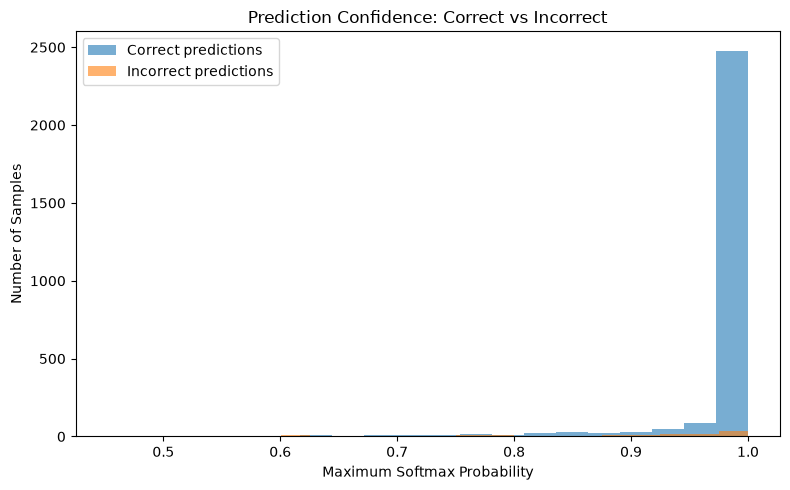

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.6,
    label="Correct predictions"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.6,
    label="Incorrect predictions"
)

plt.xlabel(
    "Maximum Softmax Probability"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Prediction Confidence: Correct vs Incorrect"
)

plt.legend()
plt.tight_layout()
plt.show()

### 16.4 High-Confidence Errors
Some incorrect predictions are made with very high confidence.
The following table shows the most confident mistakes made by the final model.

In [ ]:
incorrect_indices = np.where(
    ~correct_mask
)[0]

mistakes_df = pd.DataFrame({
    "Index": incorrect_indices,
    "True Activity": [
        target_names[
            y_test_model.iloc[i]
        ]
        for i in incorrect_indices
    ],
    "Predicted Activity": [
        target_names[
            regularized_test_pred[i]
        ]
        for i in incorrect_indices
    ],
    "Confidence": [
        regularized_test_prob[
            i,
            regularized_test_pred[i]
        ]
        for i in incorrect_indices
    ]
})

top_mistakes = (
    mistakes_df
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_mistakes.index = np.arange(
    1,
    len(top_mistakes) + 1
)

top_mistakes.index.name = "Error #"

top_mistakes

,Index,True Activity,Predicted Activity,Confidence
Error #,,,,
1,1152,WALKING,WALKING_DOWNSTAIRS,1.000000
2,1151,WALKING,WALKING_DOWNSTAIRS,0.999927
3,2526,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,0.999919
4,791,SITTING,WALKING_UPSTAIRS,0.999792
5,756,WALKING_UPSTAIRS,WALKING,0.999792
6,732,WALKING_UPSTAIRS,WALKING,0.999781
7,1153,WALKING,WALKING_DOWNSTAIRS,0.999777
8,2537,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,0.999745
9,1091,SITTING,STANDING,0.999726


In [ ]:
error_pairs_df.to_csv(
    RESULTS_DIR / "largest_confusion_pairs.csv",
    index=False
)

class_metrics.to_csv(
    RESULTS_DIR / "regularized_mlp_class_metrics.csv"
)

top_mistakes.to_csv(
    RESULTS_DIR / "top_confident_errors.csv"
)

print(
    "Error-analysis results saved."
)

Error-analysis results saved.


### Error Analysis Summary

The final Regularised Deep MLP generalised strongly to unseen test participants, but its errors were not evenly distributed across classes.
The main failure mode involved confusion between similar activities. SITTING and STANDING were frequently confused, while several errors also occurred among WALKING, WALKING_UPSTAIRS, and WALKING_DOWNSTAIRS.
LAYING was the easiest activity for the model and achieved perfect class-level performance.
Correct predictions were generally more confident than incorrect predictions. However, some incorrect predictions still received very high Softmax confidence scores, showing that confidence should not be interpreted directly as a calibrated probability of correctness.
Overall, the error patterns suggest that the model captures broad movement differences effectively but has more difficulty separating activities with similar inertial signatures.

## 17. Final Comparison, Limitations, and Conclusion

In [ ]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Majority Class Baseline",
        "Validation Accuracy": dummy_val_accuracy,
        "Test Accuracy": np.nan
    },
    {
        "Model": "Logistic Regression",
        "Validation Accuracy": logreg_val_accuracy,
        "Test Accuracy": logreg_test_accuracy
    },
    {
        "Model": "Keras Linear Softmax",
        "Validation Accuracy": linear_val_accuracy,
        "Test Accuracy": np.nan
    },
    {
        "Model": "Small MLP (64 ReLU)",
        "Validation Accuracy": small_mlp_val_accuracy,
        "Test Accuracy": np.nan
    },
    {
        "Model": "Deep MLP (256-128-64)",
        "Validation Accuracy": deep_val_accuracy,
        "Test Accuracy": np.nan
    },
    {
        "Model": "Regularised Deep MLP",
        "Validation Accuracy": regularized_val_accuracy,
        "Test Accuracy": regularized_test_accuracy
    }
])

final_model_comparison

,Model,Validation Accuracy,Test Accuracy
0,Majority Class Baseline,0.193878,NaN
1,Logistic Regression,0.956122,0.948422
2,Keras Linear Softmax,0.947959,NaN
3,Small MLP (64 ReLU),0.945918,NaN
4,Deep MLP (256-128-64),0.937245,NaN
5,Regularised Deep MLP,0.952041,0.950797


In [ ]:
final_model_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)
print("Final model comparison saved.")

Final model comparison saved.


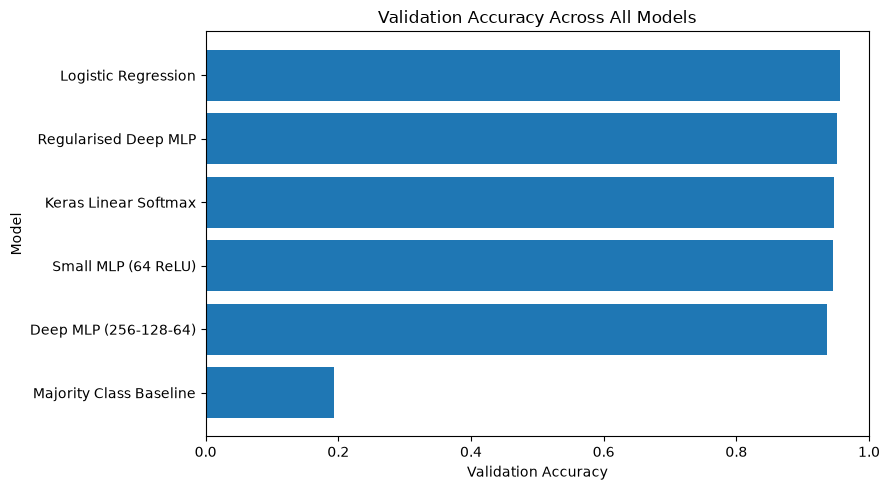

In [ ]:
plot_df = (
    final_model_comparison
    .dropna(subset=["Validation Accuracy"])
    .sort_values(
        "Validation Accuracy",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Model"],
    plot_df["Validation Accuracy"]
)

plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.title("Validation Accuracy Across All Models")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### 17.1 Model Comparison

The experiments show that increasing model complexity did not automatically improve generalisation.
The majority-class baseline achieved only about 19% validation accuracy, demonstrating that useful classification requires learning from the sensor features.
Logistic Regression achieved the strongest validation performance at 95.61%, showing that the 561 engineered HAR features are already highly informative and can be separated effectively using a linear model.
The Keras Linear Softmax model achieved 94.80% validation accuracy, while the Small MLP achieved 94.59%.

Increasing the network depth further reduced validation accuracy to 93.72% in the unregularised deep MLP. This suggests that the additional model capacity increased the risk of overfitting rather than improving generalisation.
Adding dropout and L2 regularisation improved the deep MLP substantially to 95.20% validation accuracy.
On the official held-out test set, Logistic Regression achieved 94.84% accuracy and the Regularised Deep MLP achieved 95.08%, giving the deep model the strongest final test performance by a small margin.

### 17.2 Effect of Regularisation

The comparison between the unregularised and regularised deep MLP provides a useful ablation.
The unregularised deep model achieved 93.72% validation accuracy, while the regularised version achieved 95.20%.
This improvement indicates that dropout and L2 weight regularisation helped control overfitting in the larger neural network.
The result also shows that architecture size alone was not sufficient to improve performance; regularisation was important for achieving stronger generalisation.

### 17.3 Limitations

This project has several limitations.

First, the dataset contains only 30 participants. Although the participant-safe split helps evaluate generalisation to unseen individuals, the relatively small number of subjects limits how confidently the results can be generalised to broader populations.
Second, the project uses the 561 engineered features supplied with the UCI HAR dataset rather than learning directly from raw accelerometer and gyroscope sequences. This simplifies the task and may reduce the advantage of deep learning because many informative transformations have already been performed before modelling.

Third, the project evaluates activity recognition using data collected in a controlled experimental setting. Real-world smartphone behaviour may include different device positions, movement patterns, noise levels, and user characteristics.

Fourth, the model still shows systematic confusion between similar activities, especially SITTING and STANDING and among the walking-related classes.
Finally, the confidence analysis shows that some incorrect predictions receive very high Softmax scores. Therefore, model confidence should not be treated as a calibrated probability of correctness.

### 17.4 Future Work

Future work could extend this project by training directly on the raw inertial signal sequences using architectures such as 1D convolutional neural networks or recurrent neural networks.

Additional participants and more diverse real-world data could improve the ability to evaluate generalisation.

Other possible extensions include subject-wise cross-validation, probability calibration, feature-ablation experiments, and investigation of uncertainty-aware prediction methods.

A further comparison between engineered-feature models and raw-signal deep learning models would help determine when deep learning provides a meaningful advantage over simpler classical approaches.

### 17.5 Conclusion

This project developed and evaluated a deep learning system for smartphone-based human activity recognition using the UCI HAR dataset.

A participant-safe validation strategy was used to reduce data leakage and provide a more realistic estimate of generalisation to unseen individuals.
Several models were compared, ranging from a majority-class baseline and Logistic Regression to multiple TensorFlow/Keras neural networks.
The strongest validation model was Logistic Regression with 95.61% accuracy, while the Regularised Deep MLP achieved 95.20% validation accuracy.
On the official held-out test set, the Regularised Deep MLP achieved the highest final accuracy of 95.08%, slightly outperforming Logistic Regression at 94.84%.
The experiments show that additional neural-network depth did not automatically improve performance. The unregularised deep network performed worse than simpler models, while dropout and L2 regularisation substantially improved generalisation.
Error analysis showed that most mistakes occurred between activities with similar movement characteristics, especially SITTING versus STANDING and among the walking-related activities. LAYING was classified perfectly.

Overall, the project demonstrates that a carefully regularised neural network can achieve strong activity-recognition performance on unseen participants. However, it also shows that simpler linear models remain highly competitive when strong engineered features are already available.

## 18. AI Tool Disclosure

ChatGPT was used as a supporting tool during the project, mainly for troubleshooting Python/Keras errors, clarifying TensorFlow and machine-learning concepts, reviewing code structure, and suggesting ways to improve the presentation of results.

AI suggestions were not accepted automatically. Code was run and checked in the local development environment, outputs were verified against the dataset, and model performance was evaluated using the actual validation and test results produced during execution.

The final experimental decisions, model comparisons, interpretation of results, error analysis, conclusions, and project submission were reviewed and understood by the author.

The author remains responsible for the accuracy of the submitted code, analysis, and written work.